# 03 — Backtest report

The walk-forward trading simulation: Kalshi's real fees, fractional-Kelly
sizing, one position per game, and — most importantly — game-level bootstrap
intervals on the PnL. Runs the same code as `make backtest`.

In [1]:
%config InlineBackend.figure_format = "retina"
import matplotlib.pyplot as plt
import numpy as np

from engine.data.store import Store

store = Store("sqlite:///../data/engine.db")

In [2]:
from engine.backtest.report import run_backtest

report = run_backtest(store, reports_dir=__import__("pathlib").Path("../reports"))
rows = [
    ("pregame (after fees)", report.pregame),
    ("pregame (zero-fee diagnostic)", report.pregame_no_fees),
    ("live (after fees)", report.live),
    ("follow-market baseline", report.follow_market),
]
print(f"{'strategy':32s} {'trades':>6} {'fees $':>8} {'PnL $':>9} {'ROI':>8} {'maxDD':>7}")
for name, r in rows:
    print(f"{name:32s} {len(r.trades):6d} {r.total_fees:8.2f} {r.total_pnl:+9.2f} "
          f"{r.roi:+8.2%} {r.max_drawdown:7.2%}")

2026-07-07 13:17:22 [info     ] opportunities built            live=35622 pregame=84


2026-07-07 13:17:23 [info     ] backtest report written        path=../reports/backtest_summary.md


strategy                         trades   fees $     PnL $      ROI   maxDD
pregame (after fees)                 30    39.83   +245.60  +24.56%  15.65%
pregame (zero-fee diagnostic)        37     0.00   +270.82  +27.08%  14.86%
live (after fees)                    42    45.60   +104.79  +10.48%  20.81%
follow-market baseline               84    19.73    -97.66   -9.77%  11.01%


In [3]:
lo, hi = report.pregame_pnl_ci
print(f"pregame PnL 95% CI (game bootstrap): [{lo:+.2f}, {hi:+.2f}]")
lo, hi = report.live_pnl_ci
print(f"live    PnL 95% CI (game bootstrap): [{lo:+.2f}, {hi:+.2f}]")
print("\nBoth straddle zero: the positive point estimates are one lucky playoff run,")
print("not demonstrated edge. See README §5 for where edge could plausibly hide.")

pregame PnL 95% CI (game bootstrap): [-234.00, +718.42]
live    PnL 95% CI (game bootstrap): [-336.88, +586.03]

Both straddle zero: the positive point estimates are one lucky playoff run,
not demonstrated edge. See README §5 for where edge could plausibly hide.


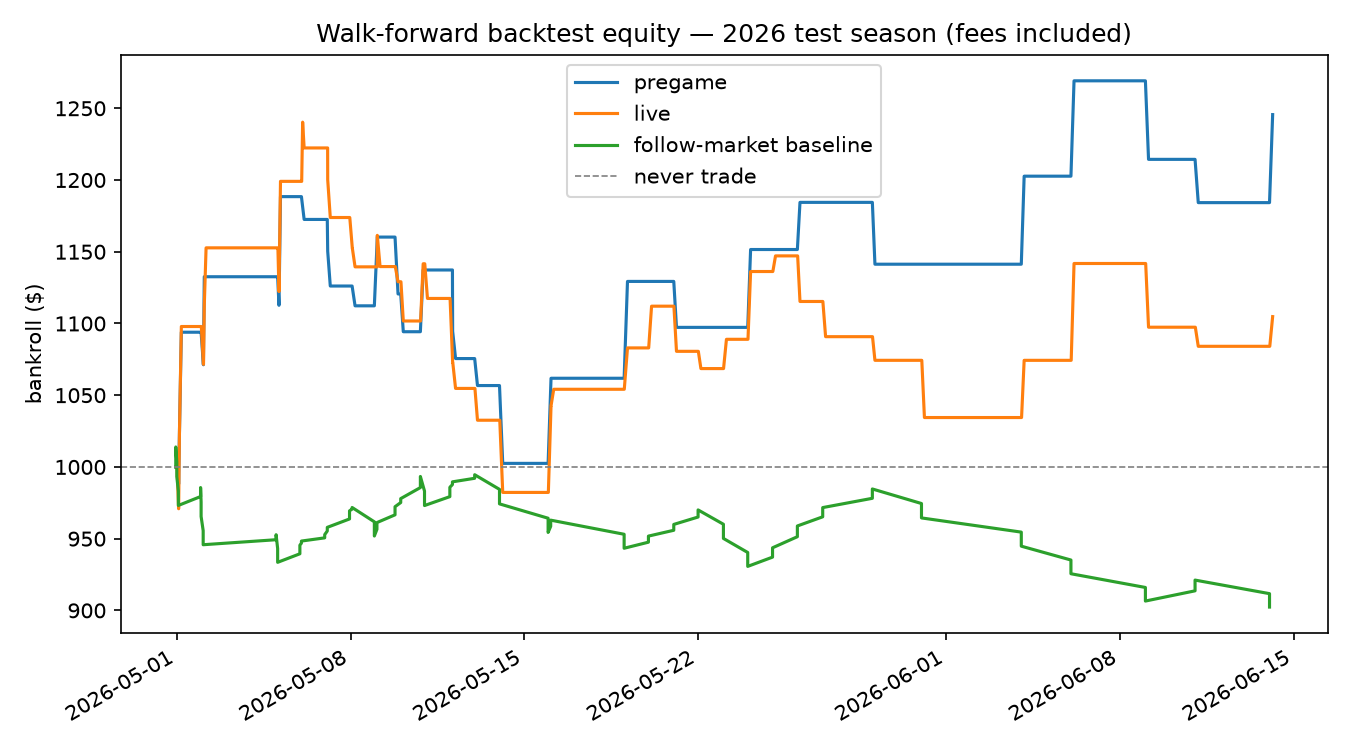

In [4]:
from IPython.display import Image

Image("../reports/equity_curve.png", width=720)

## Trade-level view

Every simulated pre-game trade: what the model believed, what the market
charged, and how it ended.

In [5]:
print(f"{'ticker':34s} {'side':4s} {'px':>3} {'model':>6} {'won':>5} {'pnl $':>8}")
for t in report.pregame.trades:
    print(f"{t.ticker:34s} {t.side.value:4s} {t.price_cents:3d} "
          f"{t.model_prob:6.3f} {str(t.won):>5} {t.pnl:+8.2f}")

ticker                             side  px  model   won    pnl $
KXNBAGAME-26APR30NYKATL-ATL        yes   43  0.473 False   -11.96
KXNBAGAME-26APR30BOSPHI-BOS        no    32  0.619  True   +35.29
KXNBAGAME-26APR30DENMIN-DEN        no    28  0.527  True   +70.58
KXNBAGAME-26MAY01DETORL-DET        no    41  0.527 False   -22.69
KXNBAGAME-26MAY01CLETOR-CLE        no    37  0.527  True   +61.36
KXNBAGAME-26MAY04PHINYK-NYK        no    29  0.649 False   -19.92
KXNBAGAME-26MAY04MINSAS-MIN        yes   23  0.378  True   +75.76
KXNBAGAME-26MAY05LALOKC-LAL        yes   15  0.455 False   -15.90
KXNBAGAME-26MAY06PHINYK-NYK        no    21  0.717 False   -22.17
KXNBAGAME-26MAY06MINSAS-MIN        yes   23  0.351 False   -24.24
KXNBAGAME-26MAY07LALOKC-LAL        yes   13  0.407 False   -13.80
KXNBAGAME-26MAY08NYKPHI-NYK        yes   42  0.509  True   +47.91
KXNBAGAME-26MAY09DETCLE-CLE        no    38  0.473 False   -39.65
KXNBAGAME-26MAY09OKCLAL-LAL        yes   25  0.473 False   -26.32
KXNBAGAME-